# PeakPredictorLSTM – Model Training

This notebook performs **supervised training** of the `PeakPredictorLSTM` model for **peak detection in time series** using synthetic data generated from a parametric *p-model*.

The objective is to train a robust LSTM-based predictor capable of **anticipating peak events** within a fixed lookahead window.

---

#### Objective

- Train an LSTM model for **peak prediction in time series**
- Minimize validation loss using **binary classification**
- Handle strong **class imbalance** between remind and peak events
- Apply **early stopping** to prevent overfitting

---

#### Dataset

- **Type:** Synthetic time series generated using a parametric *p-model*
- **Training set:** Multiple generated time series
- **Validation set:** Independent generated time series
- **Test set:** Independent generated time series
- **Labels:** Binary peak occurrence within a future lookahead window

---

#### Training Setup

- **Model:** Multi-layer LSTM with input projection and SiLU activations
- **Optimizer:** Adam
- **Loss function:** `BCEWithLogitsLoss` with dynamic positive class weighting
- **Early stopping:** Enabled based on validation loss
- **Device:** CPU / CUDA / Apple MPS (automatically selected)

---

#### Output

- Best-performing model saved to `/results/best_model.pth`
- Training and validation loss curves
- Example visualizations of generated p-model time series

---

#### Author

**Carlos Eduardo Falandes**  
M.Sc. Student in Applied Computing  
National Institute for Space Research (INPE)  
📧 carlos.falandes@inpe.br


In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path().resolve().parents[1]
sys.path.append(str(ROOT_DIR))


In [2]:
import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

import matplotlib as mpl

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']

from src.models.model import PeakPredictorLSTM
from src.data.pmodel_generation import (
    generate_multiple_series,
    create_sequences,
    plot_generated_series,
)


In [3]:
def prepare_dataloader_from_series(
    series_list,
    window_size,
    lookahead,
    batch_size
):
    """
    Creates a PyTorch DataLoader from multiple p-model time series.
    """
    X_all, y_all = [], []

    for df in series_list:
        X, y = create_sequences(df, window_size, lookahead)

        if len(X) == 0:
            continue

        X_all.append(X)
        y_all.append(y)

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)

    dataset = TensorDataset(
        torch.tensor(X_all, dtype=torch.float32),
        torch.tensor(y_all, dtype=torch.float32)
    )

    return DataLoader(dataset, batch_size=batch_size, shuffle=True)


In [4]:
def compute_pos_weight(dataloader, device):
    """
    Computes the positive class weight for imbalanced binary classification.
    """
    total_pos = 0
    total_neg = 0

    for _, y in dataloader:
        total_pos += (y == 1).sum().item()
        total_neg += (y == 0).sum().item()

    pos_weight = total_neg / max(total_pos, 1)
    return torch.tensor([pos_weight], device=device)


In [5]:
def train_model(
    model,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    epochs,
    device,
    start_epoch=0,
    history=None,
    best_val_loss=float("inf"),
    patience=10,
    checkpoint_path=None,
    model_save_path="../../results/best_model.pth"
):
    """
    Trains the model with early stopping and supports resume training.
    """

    if history is None:
        history = {"train_loss": [], "val_loss": []}

    epochs_without_improvement = 0

    for epoch in range(start_epoch + 1, start_epoch + epochs + 1):
        # -------- Training --------
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in tqdm(
            train_loader,
            desc=f"Epoch {epoch} - Training"
        ):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch).squeeze(-1)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # -------- Validation --------
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)

                outputs = model(X_val).squeeze(-1)
                loss = criterion(outputs, y_val)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        print(
            f"Epoch {epoch}: "
            f"Train Loss = {train_loss:.6f} | "
            f"Val Loss = {val_loss:.6f}"
        )

        # -------- Early stopping + best model --------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0

            torch.save(model.state_dict(), model_save_path)
            print(f"✔ Best model saved (Val Loss = {best_val_loss:.6f})")
        else:
            epochs_without_improvement += 1

        # -------- History --------
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # -------- Checkpoint (resume) --------
        if checkpoint_path is not None:
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "history": history,
                "best_val_loss": best_val_loss
            }, checkpoint_path)

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

    print("\nTraining finished.")

    return history


In [6]:
import os

def save_series_list(series_list, split_name, base_dir="../../data"):
    """
    Saves a list of time series DataFrames to CSV files.

    Parameters
    ----------
    series_list : list of pd.DataFrame
        Generated time series
    split_name : str
        One of ['train', 'val', 'test']
    base_dir : str
        Base directory to store data
    """
    split_dir = os.path.join(base_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)

    for i, df in enumerate(series_list):
        filename = f"{split_name}_series_{i:03d}.csv"
        path = os.path.join(split_dir, filename)
        df.to_csv(path, index=False)

    print(f"💾 Saved {len(series_list)} {split_name} series to '{split_dir}'")


In [7]:
def main():
    np.random.seed(20)

    with open("../../config/config_endo.json", "r") as f:
        config = json.load(f)

    # -------- Paths --------
    checkpoint_path = "../../results/checkpoint.pth"
    best_model_path = "../../results/best_model.pth"

    # -------- Device selection --------
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    print(f"Using device: {device}")

    # -------- Model --------
    model = PeakPredictorLSTM(config["model"]).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["training"]["learning_rate"]
    )

    print("\nModel architecture:")
    print(model)

    # -------- Resume variables --------
    start_epoch = 0
    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")

    # -------- Load checkpoint if exists --------
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)

        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        start_epoch = checkpoint["epoch"]
        history = checkpoint["history"]
        best_val_loss = checkpoint["best_val_loss"]

        print(f"🔄 Retomando treinamento da época {start_epoch}")
    else:
        print("🆕 Iniciando treinamento do zero")

    # -------- Data generation --------
    train_series = generate_multiple_series(
        length=config["p_model"]["series_length"],
        p_value=config["p_model"]["p_value"],
        num_series=config["data"]["num_series_train"],
        peak_percentile=config["data"]["peak_percentile"],
    )

    val_series = generate_multiple_series(
        length=config["p_model"]["series_length"],
        p_value=config["p_model"]["p_value"],
        num_series=config["data"]["num_series_validation"],
        peak_percentile=config["data"]["peak_percentile"],
    )

    test_series = generate_multiple_series(
        length=config["p_model"]["series_length"],
        p_value=config["p_model"]["p_value"],
        num_series=config["data"]["num_series_test"],
        peak_percentile=config["data"]["peak_percentile"],
    )

    # -------- Save generated series --------
    save_series_list(train_series, "train")
    save_series_list(val_series, "val")
    save_series_list(test_series, "test")

    # -------- Visualization --------
    plot_generated_series(train_series[0], title="Training Series Example")
    plot_generated_series(val_series[0], title="Validation Series Example")
    plot_generated_series(test_series[0], title="Test Series Example")

    # -------- Dataloaders --------
    train_loader = prepare_dataloader_from_series(
        train_series,
        config["data"]["window_size"],
        config["data"]["lookahead"],
        config["training"]["batch_size"],
    )

    val_loader = prepare_dataloader_from_series(
        val_series,
        config["data"]["window_size"],
        config["data"]["lookahead"],
        config["training"]["batch_size"],
    )

    # -------- Loss --------
    raw_pos_weight = compute_pos_weight(train_loader, device)
    pos_weight = torch.clamp(raw_pos_weight, max=7.0)

    print(f"⚖️ Positive class weight (clipped): {pos_weight.item():.2f}")

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # -------- Training --------
    history = train_model(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=config["training"]["epochs"],  # épocas ADICIONAIS
        device=device,
        start_epoch=start_epoch,
        history=history,
        best_val_loss=best_val_loss,
        checkpoint_path=checkpoint_path,
        model_save_path=best_model_path,
    )

    return history


Using device: mps

Model architecture:
PeakPredictorLSTM(
  (input_projection): Linear(in_features=1, out_features=32, bias=True)
  (silu): SiLU()
  (lstm_layers): ModuleList(
    (0): LSTM(32, 64, batch_first=True)
  )
  (dropout): Dropout(p=0.34, inplace=False)
  (output_projection): Linear(in_features=64, out_features=1, bias=True)
)
🆕 Iniciando treinamento do zero
💾 Saved 7000 train series to '../../data/train'
💾 Saved 1500 val series to '../../data/val'
💾 Saved 1500 test series to '../../data/test'


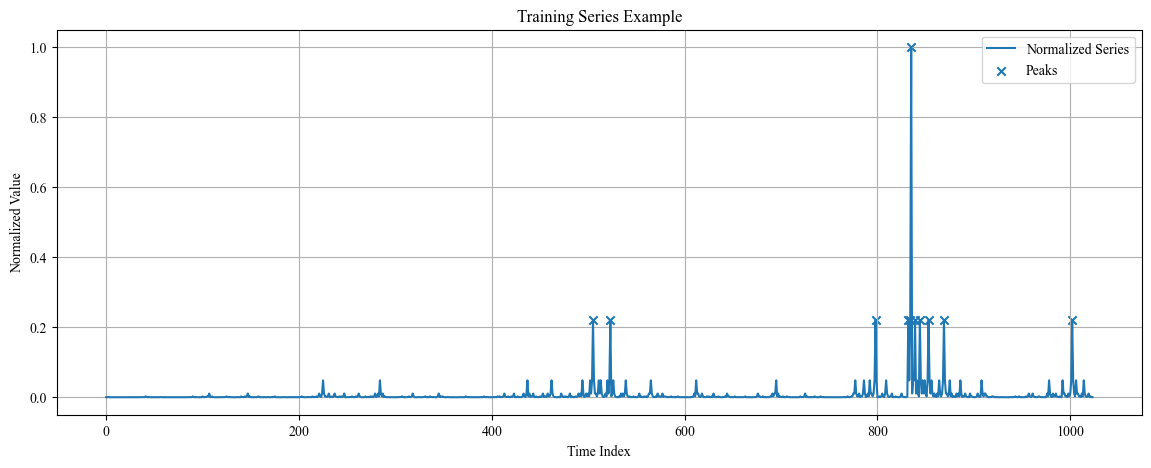

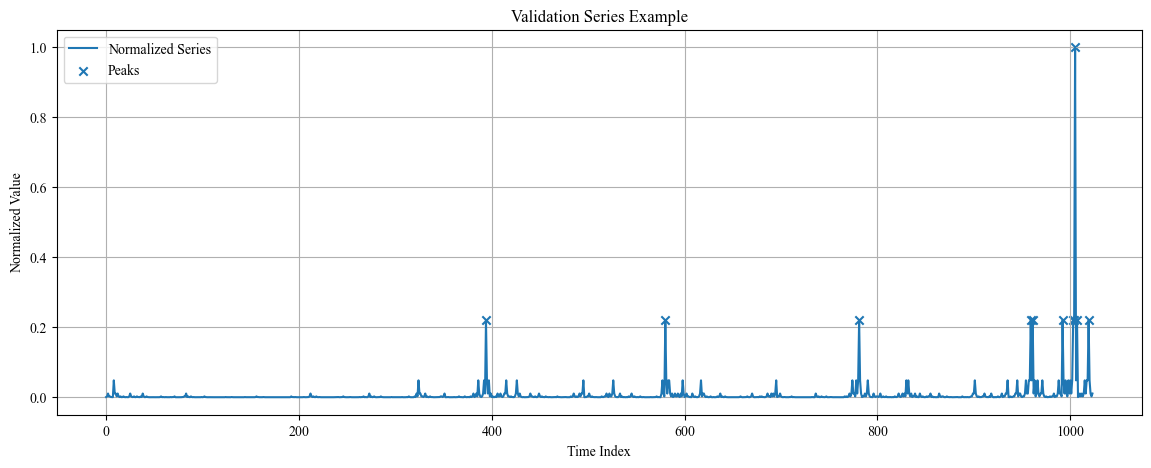

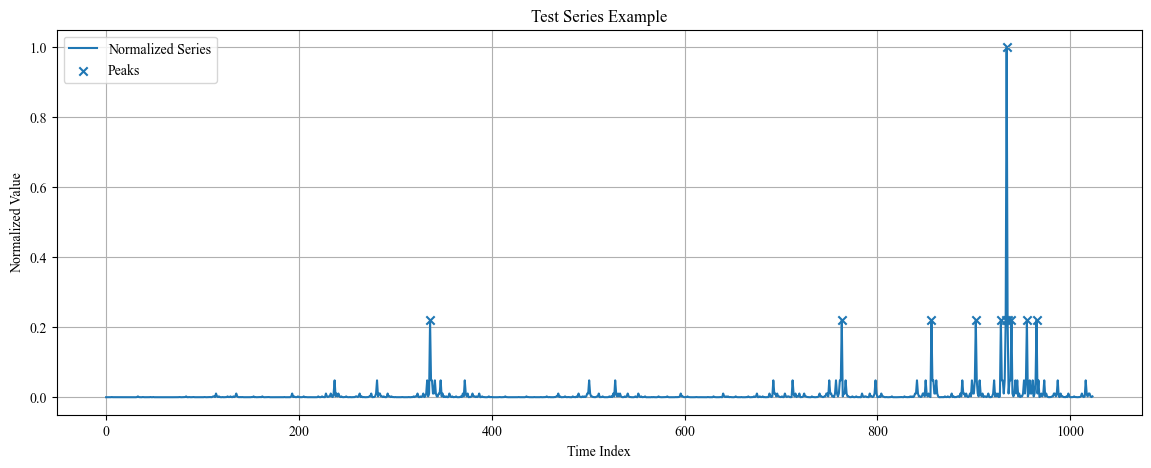

⚖️ Positive class weight (clipped): 7.00


Epoch 1 - Training: 100%|██████████| 34508/34508 [12:00<00:00, 47.91it/s]


Epoch 1: Train Loss = 0.924188 | Val Loss = 0.898961
✔ Best model saved (Val Loss = 0.898961)


Epoch 2 - Training: 100%|██████████| 34508/34508 [11:56<00:00, 48.19it/s]


Epoch 2: Train Loss = 0.874696 | Val Loss = 0.908930


...

Epoch 198: Train Loss = 0.449066 | Val Loss = 0.462899


Epoch 199 - Training: 100%|██████████| 34508/34508 [14:48<00:00, 38.86it/s]


Epoch 199: Train Loss = 0.448769 | Val Loss = 0.463024


Epoch 200 - Training: 100%|██████████| 34508/34508 [15:00<00:00, 38.32it/s]


Epoch 200: Train Loss = 0.448380 | Val Loss = 0.469599

Training finished.


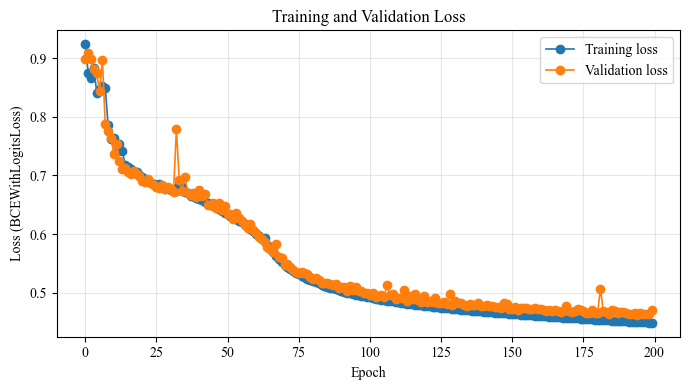

Processing time: 3057 min 54.44 s


In [8]:
import time

if __name__ == '__main__':
    inicio = time.perf_counter()
    history = main()
        
    # -------- Loss curves --------
    plt.figure(figsize=(7, 4))
    plt.plot(
        history["train_loss"],
        label="Training loss",
        linewidth=1.2,
        markersize=6,
        marker="o"
    )
    plt.plot(
        history["val_loss"],
        label="Validation loss",
        linewidth=1.2,
        markersize=6,
        marker="o"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss (BCEWithLogitsLoss)")
    plt.legend(frameon=True, fontsize=10)
    plt.title("Training and Validation Loss")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



    fim = time.perf_counter()

    duracao = fim - inicio
    minutes = int(duracao // 60)
    seconds = duracao % 60

    print(f"Processing time: {minutes} min {seconds:.2f} s")


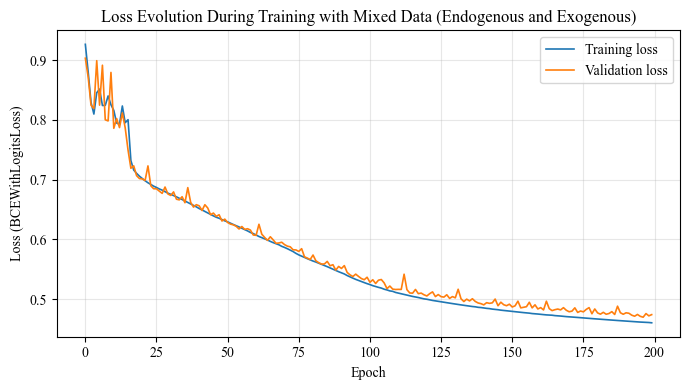

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(
    history["train_loss"],
    label="Training loss",
    linewidth=1.2,
    markersize=6
)
plt.plot(
    history["val_loss"],
    label="Validation loss",
    linewidth=1.2,
    markersize=6
)
plt.xlabel("Epoch")
plt.ylabel("Loss (BCEWithLogitsLoss)")
plt.legend(frameon=True, fontsize=10)
plt.title("Loss Evolution During Training with Mixed Data (Endogenous and Exogenous)")
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("training_history_loss.pdf")  
plt.show()

Using device: mps

Model architecture:
PeakPredictorLSTM(
  (input_projection): Linear(in_features=1, out_features=32, bias=True)
  (silu): SiLU()
  (lstm_layers): ModuleList(
    (0): LSTM(32, 64, batch_first=True)
  )
  (dropout): Dropout(p=0.34, inplace=False)
  (output_projection): Linear(in_features=64, out_features=1, bias=True)
)
🆕 Iniciando treinamento do zero
💾 Saved 7000 train series to '../../data/train'
💾 Saved 1500 val series to '../../data/val'
💾 Saved 1500 test series to '../../data/test'


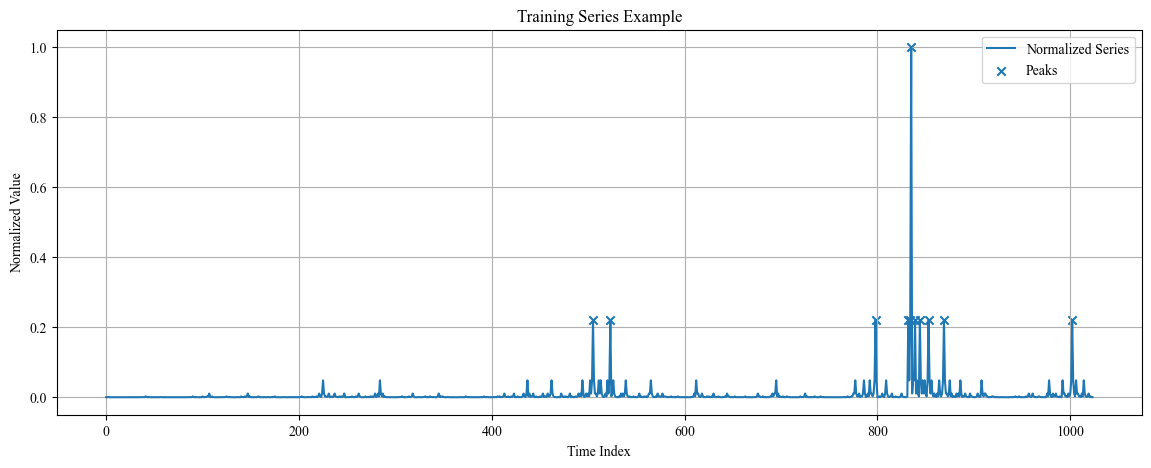

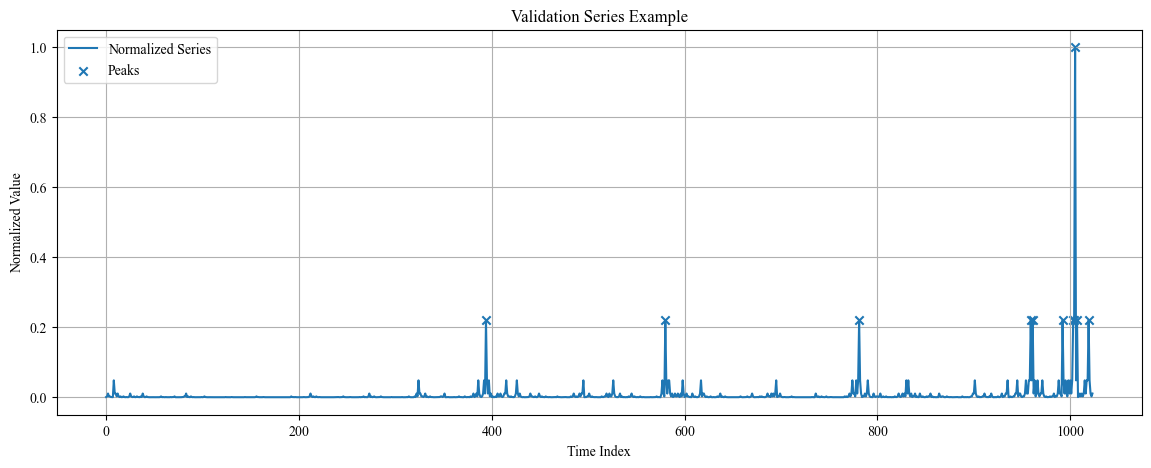

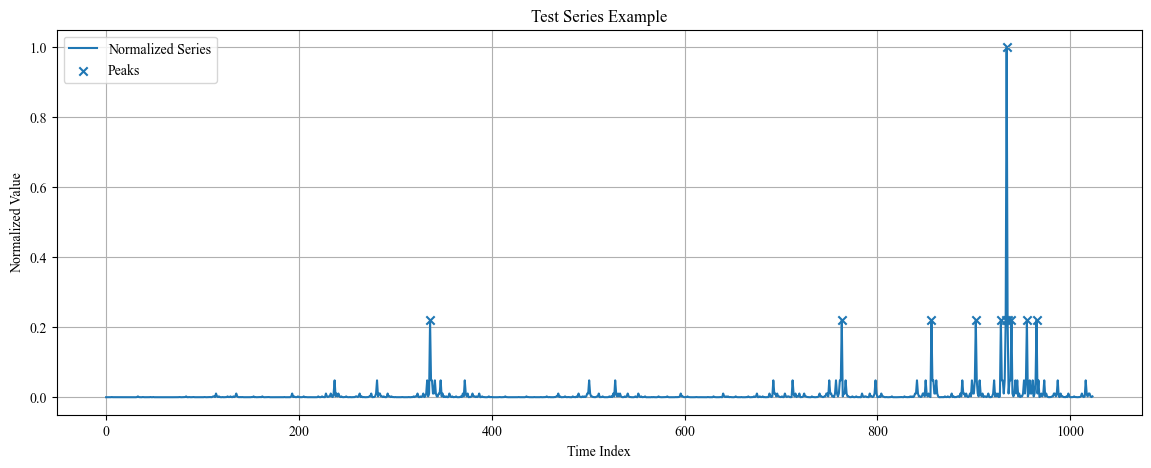

⚖️ Positive class weight (clipped): 7.00


Epoch 1 - Training: 100%|██████████| 34508/34508 [12:18<00:00, 46.71it/s]


Epoch 1: Train Loss = 0.926454 | Val Loss = 0.903246
✔ Best model saved (Val Loss = 0.903246)


Epoch 2 - Training: 100%|██████████| 34508/34508 [15:31<00:00, 37.06it/s]


Epoch 2: Train Loss = 0.880031 | Val Loss = 0.871428
✔ Best model saved (Val Loss = 0.871428)


...

Epoch 198: Train Loss = 0.461283 | Val Loss = 0.475896


Epoch 199 - Training: 100%|██████████| 34508/34508 [12:29<00:00, 46.03it/s]


Epoch 199: Train Loss = 0.460980 | Val Loss = 0.472121


Epoch 200 - Training: 100%|██████████| 34508/34508 [12:26<00:00, 46.23it/s]


Epoch 200: Train Loss = 0.460485 | Val Loss = 0.474152

Training finished.


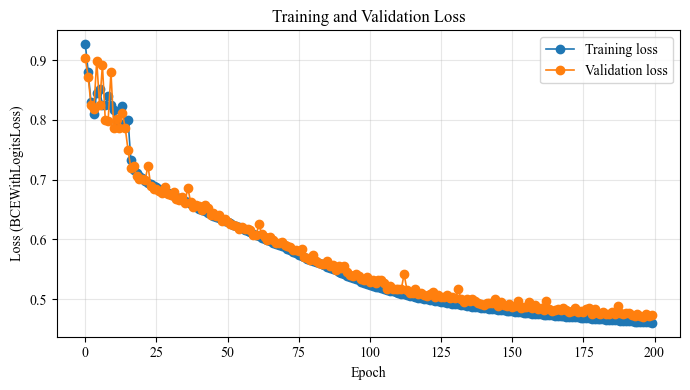

Processing time: 3090 min 18.43 s


In [10]:
import time

if __name__ == '__main__':
    inicio = time.perf_counter()
    history = main()
        
    # -------- Loss curves --------
    plt.figure(figsize=(7, 4))
    plt.plot(
        history["train_loss"],
        label="Training loss",
        linewidth=1.2,
        markersize=6,
        marker="o"
    )
    plt.plot(
        history["val_loss"],
        label="Validation loss",
        linewidth=1.2,
        markersize=6,
        marker="o"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss (BCEWithLogitsLoss)")
    plt.legend(frameon=True, fontsize=10)
    plt.title("Training and Validation Loss")
    plt.grid(alpha=0.3)
    plt.tight_layout() 
    plt.show()



    fim = time.perf_counter()

    duracao = fim - inicio
    minutes = int(duracao // 60)
    seconds = duracao % 60

    print(f"Processing time: {minutes} min {seconds:.2f} s")


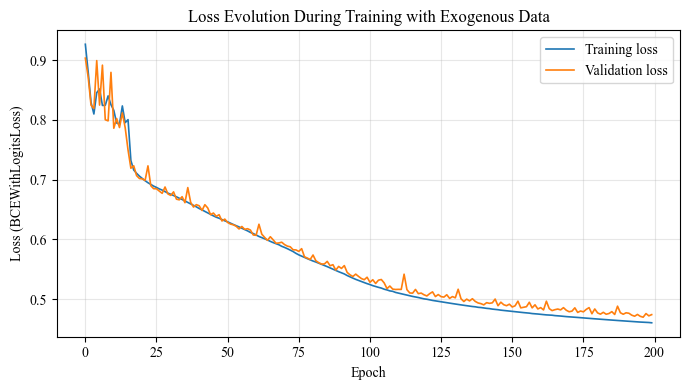

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(
    history["train_loss"],
    label="Training loss",
    linewidth=1.2,
    markersize=6
)
plt.plot(
    history["val_loss"],
    label="Validation loss",
    linewidth=1.2,
    markersize=6
)
plt.xlabel("Epoch")
plt.ylabel("Loss (BCEWithLogitsLoss)")
plt.legend(frameon=True, fontsize=10)
plt.title("Loss Evolution During Training with Exogenous Data")
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("training_history_loss.pdf")  
plt.show()

Using device: mps

Model architecture:
PeakPredictorLSTM(
  (input_projection): Linear(in_features=1, out_features=32, bias=True)
  (silu): SiLU()
  (lstm_layers): ModuleList(
    (0): LSTM(32, 64, batch_first=True)
  )
  (dropout): Dropout(p=0.34, inplace=False)
  (output_projection): Linear(in_features=64, out_features=1, bias=True)
)
🆕 Iniciando treinamento do zero
💾 Saved 7000 train series to '../../data/train'
💾 Saved 1500 val series to '../../data/val'
💾 Saved 1500 test series to '../../data/test'


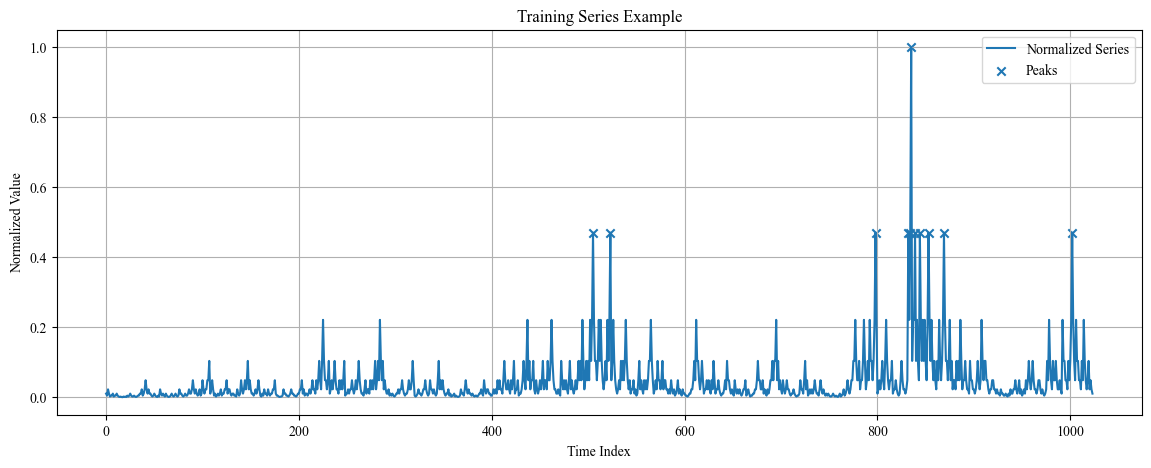

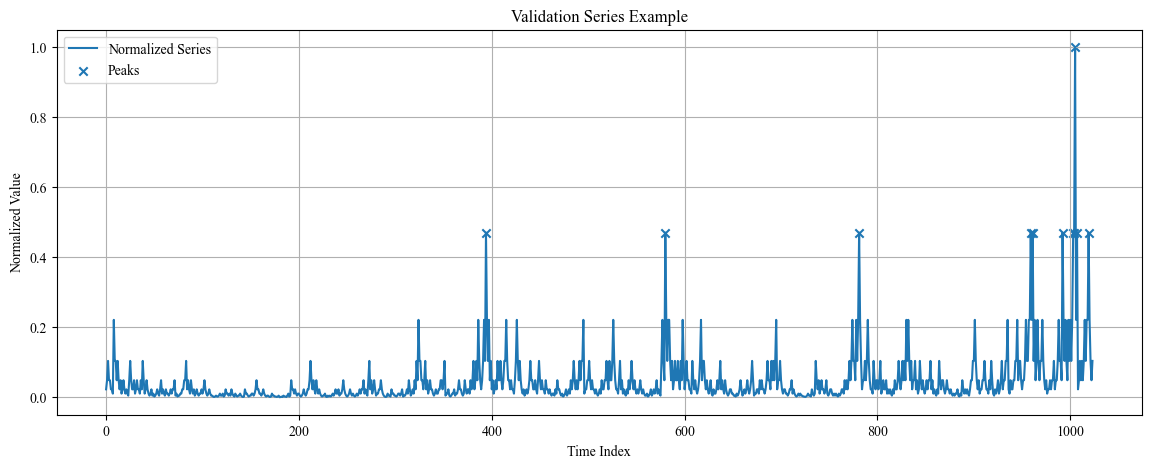

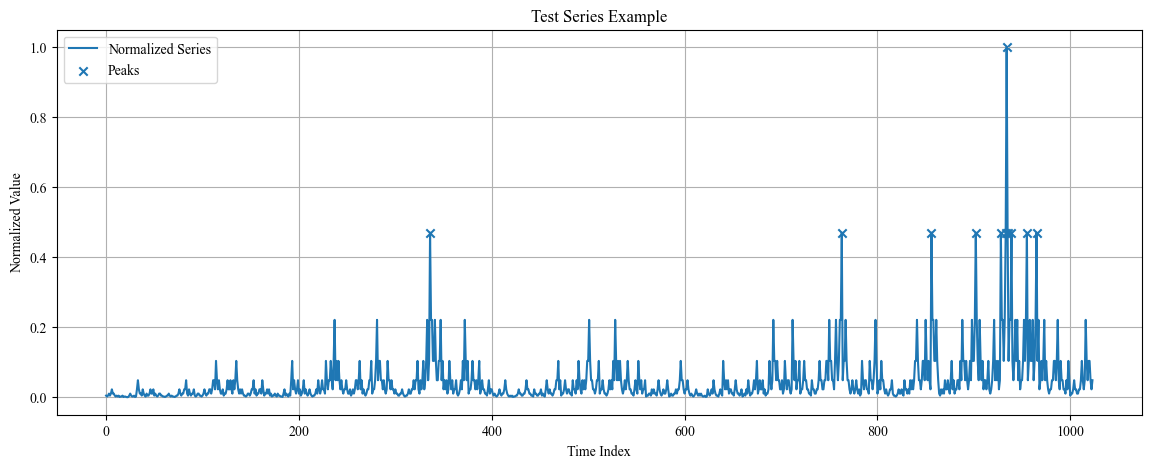

⚖️ Positive class weight (clipped): 7.00


Epoch 1 - Training: 100%|██████████| 34508/34508 [14:34<00:00, 39.45it/s]


Epoch 1: Train Loss = 0.840942 | Val Loss = 0.796329
✔ Best model saved (Val Loss = 0.796329)


Epoch 2 - Training: 100%|██████████| 34508/34508 [13:58<00:00, 41.17it/s]


Epoch 2: Train Loss = 0.783169 | Val Loss = 0.797948


...

Epoch 190: Train Loss = 0.439283 | Val Loss = 0.455362


Epoch 191 - Training: 100%|██████████| 34508/34508 [13:49<00:00, 41.59it/s]


Epoch 191: Train Loss = 0.438952 | Val Loss = 0.453350


Epoch 192 - Training: 100%|██████████| 34508/34508 [14:10<00:00, 40.56it/s]


Epoch 192: Train Loss = 0.438780 | Val Loss = 0.454037

Early stopping triggered at epoch 192.

Training finished.


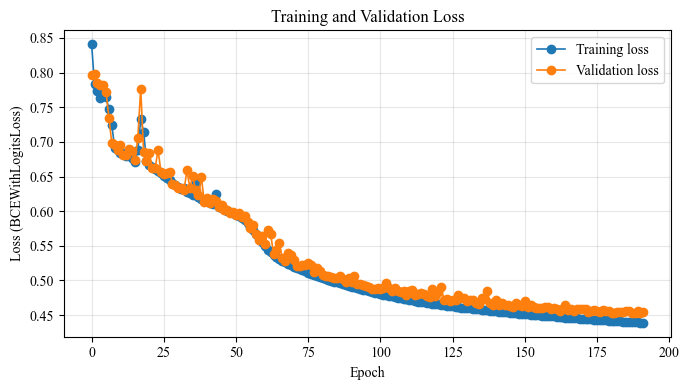

Processing time: 3057 min 51.47 s


In [8]:
import time

if __name__ == '__main__':
    inicio = time.perf_counter()
    history_endo = main()
        
    # -------- Loss curves --------
    plt.figure(figsize=(7, 4))
    plt.plot(
        history_endo["train_loss"],
        label="Training loss",
        linewidth=1.2,
        markersize=6,
        marker="o"
    )
    plt.plot(
        history_endo["val_loss"],
        label="Validation loss",
        linewidth=1.2,
        markersize=6,
        marker="o"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss (BCEWithLogitsLoss)")
    plt.legend(frameon=True, fontsize=10)
    plt.title("Training and Validation Loss")
    plt.grid(alpha=0.3)
    plt.tight_layout() 
    plt.show()



    fim = time.perf_counter()

    duracao = fim - inicio
    minutes = int(duracao // 60)
    seconds = duracao % 60

    print(f"Processing time: {minutes} min {seconds:.2f} s")


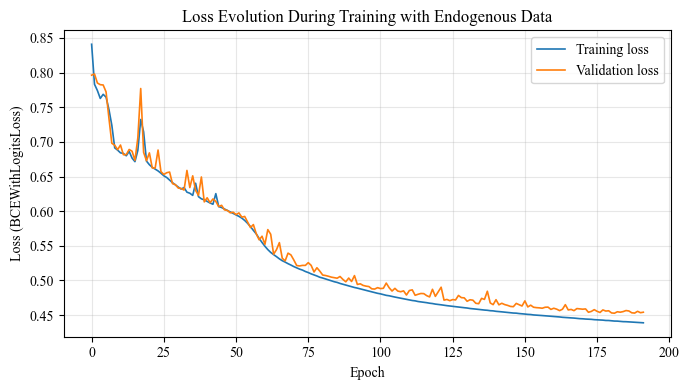

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(
    history_endo["train_loss"],
    label="Training loss",
    linewidth=1.2,
    markersize=6
)
plt.plot(
    history_endo["val_loss"],
    label="Validation loss",
    linewidth=1.2,
    markersize=6
)
plt.xlabel("Epoch")
plt.ylabel("Loss (BCEWithLogitsLoss)")
plt.legend(frameon=True, fontsize=10)
plt.title("Loss Evolution During Training with Endogenous Data")
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("training_history_loss.pdf")  
plt.show()